In [33]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns 

In [34]:
df = pd.read_csv("../data/swap_transactions.csv",parse_dates=["timestamp"])

In [35]:
df1=df.copy()

In [36]:
df1.describe()

,timestamp,battery_soc_returned,battery_soc_issued,wait_minutes,swap_duration_minutes,batteries_available_before_swap,downtime_minutes,payment_amount
count,30000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,2026-04-01 13:29:56.015466496,24.113617,93.861427,3.930030,3.511617,13.448567,0.232433,35.538836
min,2026-01-01 06:02:33,3.000000,78.000000,0.200000,1.200000,0.000000,0.000000,0.000000
25%,2026-02-14 18:36:31,16.600000,91.300000,1.600000,3.000000,10.000000,0.000000,34.840000
50%,2026-04-01 17:30:55,24.000000,93.900000,3.000000,3.500000,14.000000,0.000000,36.770000
75%,2026-05-16 18:56:02.500000,31.400000,96.600000,5.100000,4.000000,17.000000,0.000000,38.800000
max,2026-06-30 23:52:34,55.000000,100.000000,45.000000,6.600000,28.000000,108.000000,45.370000
std,NaN,10.751938,3.734176,3.572835,0.779157,5.649668,3.121965,7.650609


In [37]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   swap_id                          30000 non-null  object        
 1   timestamp                        30000 non-null  datetime64[ns]
 2   station_id                       30000 non-null  object        
 3   battery_soc_returned             30000 non-null  float64       
 4   battery_soc_issued               30000 non-null  float64       
 5   wait_minutes                     30000 non-null  float64       
 6   swap_duration_minutes            30000 non-null  float64       
 7   batteries_available_before_swap  30000 non-null  int64         
 8   station_status                   30000 non-null  object        
 9   downtime_minutes                 30000 non-null  int64         
 10  payment_amount                   30000 non-null  float64  

In [38]:
print(df1.isna().sum())

swap_id                            0
timestamp                          0
station_id                         0
battery_soc_returned               0
battery_soc_issued                 0
wait_minutes                       0
swap_duration_minutes              0
batteries_available_before_swap    0
station_status                     0
downtime_minutes                   0
payment_amount                     0
payment_method                     0
motorcycle_type                    0
service_success                    0
dtype: int64


In [39]:
print(df1.duplicated().sum())

0


In [40]:
df1= df1[["swap_id","timestamp","station_id","battery_soc_returned","battery_soc_issued","wait_minutes","swap_duration_minutes","batteries_available_before_swap","station_status","downtime_minutes",]]

In [41]:
df1

,swap_id,timestamp,station_id,battery_soc_returned,battery_soc_issued,wait_minutes,swap_duration_minutes,batteries_available_before_swap,station_status,downtime_minutes
0,SW000001,2026-01-01 06:02:33,ST001,34.1,93.2,0.6,4.5,12,Operational,0
1,SW000002,2026-01-01 06:32:12,ST004,41.2,95.9,2.8,3.7,16,Operational,0
2,SW000003,2026-01-01 06:46:12,ST005,24.9,85.8,1.2,2.9,15,Operational,0
3,SW000004,2026-01-01 06:50:15,ST004,19.6,91.2,9.6,4.5,24,Operational,0
4,SW000005,2026-01-01 06:59:01,ST004,31.7,95.5,4.7,3.2,19,Operational,0
...,...,...,...,...,...,...,...,...,...,...
29995,SW029996,2026-06-30 22:42:16,ST002,32.5,100.0,1.9,4.4,8,Operational,0
29996,SW029997,2026-06-30 22:54:17,ST003,5.8,96.6,4.0,3.2,1,Operational,0
29997,SW029998,2026-06-30 23:16:49,ST004,17.6,98.3,5.5,4.2,15,Operational,0
29998,SW029999,2026-06-30 23:21:50,ST002,20.6,95.5,1.8,4.3,20,Operational,0


In [42]:
print(df["station_id"].unique())

['ST001' 'ST004' 'ST005' 'ST002' 'ST003']


In [43]:
station_lookup = {"ST001":"Adenta","ST002":"Haatso","ST003":"Spintex","ST004":"Kaneshie","ST005":"Abelenpke"}

In [44]:
df1["station_name"] = df["station_id"].map(station_lookup)

In [45]:
df1

,swap_id,timestamp,station_id,battery_soc_returned,battery_soc_issued,wait_minutes,swap_duration_minutes,batteries_available_before_swap,station_status,downtime_minutes,station_name
0,SW000001,2026-01-01 06:02:33,ST001,34.1,93.2,0.6,4.5,12,Operational,0,Adenta
1,SW000002,2026-01-01 06:32:12,ST004,41.2,95.9,2.8,3.7,16,Operational,0,Kaneshie
2,SW000003,2026-01-01 06:46:12,ST005,24.9,85.8,1.2,2.9,15,Operational,0,Abelenpke
3,SW000004,2026-01-01 06:50:15,ST004,19.6,91.2,9.6,4.5,24,Operational,0,Kaneshie
4,SW000005,2026-01-01 06:59:01,ST004,31.7,95.5,4.7,3.2,19,Operational,0,Kaneshie
...,...,...,...,...,...,...,...,...,...,...,...
29995,SW029996,2026-06-30 22:42:16,ST002,32.5,100.0,1.9,4.4,8,Operational,0,Haatso
29996,SW029997,2026-06-30 22:54:17,ST003,5.8,96.6,4.0,3.2,1,Operational,0,Spintex
29997,SW029998,2026-06-30 23:16:49,ST004,17.6,98.3,5.5,4.2,15,Operational,0,Kaneshie
29998,SW029999,2026-06-30 23:21:50,ST002,20.6,95.5,1.8,4.3,20,Operational,0,Haatso


In [48]:
#total swaps by stations

total_swaps = df1.groupby("station_name")["station_id"].count()

In [49]:
total_swaps

station_name
Abelenpke    4026
Adenta       7912
Haatso       4945
Kaneshie     6196
Spintex      6921
Name: station_id, dtype: int64

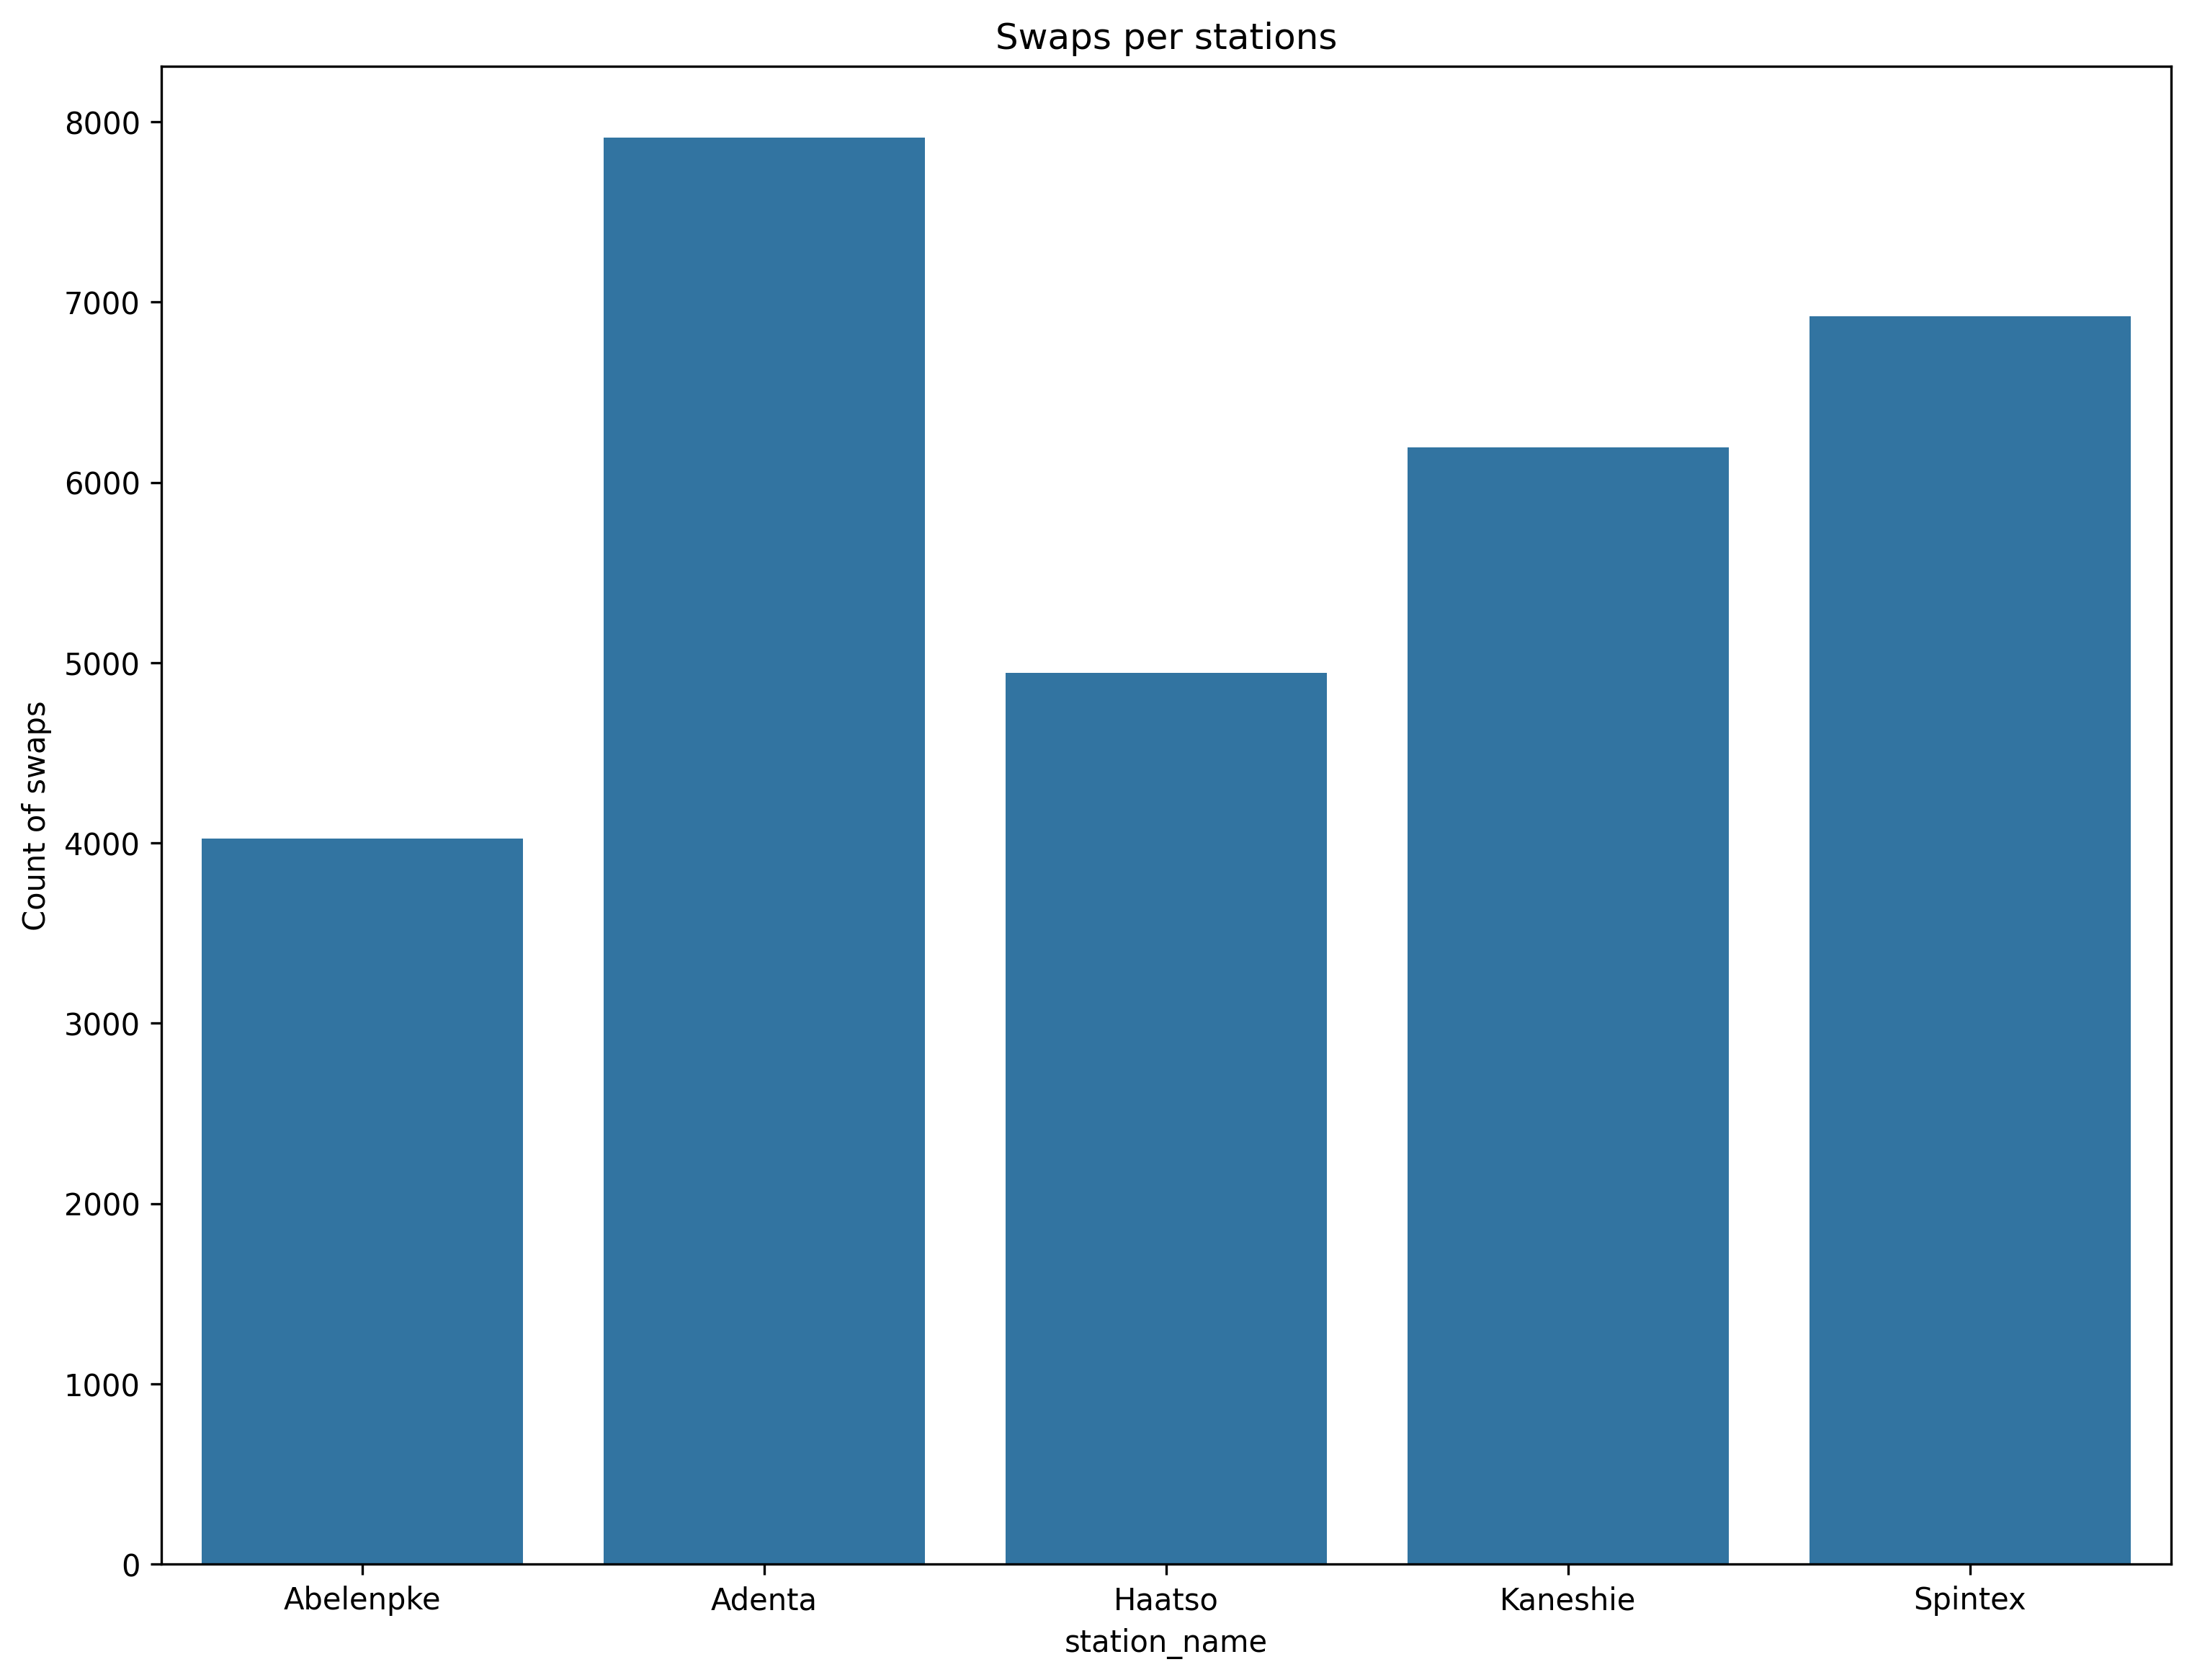

In [51]:
plt.figure(figsize=(12,9),dpi=300)
sns.barplot(data=total_swaps)
plt.title("Swaps per stations")
plt.ylabel("Count of swaps")
plt.show()